# Lấy dữ liệu từ Endpont API bằng thư viện Requests

- Thư viện requests là một thư viện HTTP đơn giản dành cho python. 
- Về cơ bản nó sử dụng để gửi yêu cầu HTTP qua các dịch vụ web API. 
- Để cài đặt nó bằng lệnh pip.

Học viên có thể tìm hiểu thêm về thư viện Requests tại đây:
[Thư viện Requests](https://docs.python-requests.org/en/latest/)


## Cài đặt thư viện requests

In [1]:
# Cài đặt thư viện
!pip install requests

## Gửi HTTP GET Requests


In [2]:
# Import thư viện requests
import requests
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# Gửi một HTTP GET request tới địa chỉ URL là https://api.kanye.rest:
# A free REST API for random Kanye West quotes (Kanye as a Service)
# Lấy kết quả requests, sau khi chạy câu lệnh get, kết quả trả về sẽ chứa thông tin response trả về từ server. 
response = requests.get("https://api.kanye.rest")

In [3]:
# Để xem dữ liệu của response trả về dưới định dạng văn bản chúng ta sử dụng câu lệnh:
print("Định dạng dữ liệu trả về: ", response.text)


Định dạng dữ liệu trả về:  {"quote":"Style is genderless"}


In [4]:
# Lấy trạng thái kết quả trả về
print(response.raise_for_status())

None


In [5]:
# Lấy dữ liệu trả về
data = response.json()


In [6]:
# Lấy value của dict trả về
quote = data["quote"]
print(quote)

Style is genderless


### Bài tập 1:

Gọi request tới API: https://api.kanye.rest để lấy 5 câu quote bất kỳ của Kanye! Tạo thành 1 dataframe gồm 3 cột:


Cột 1: Id - Số thứ tự (Bắt đầu từ số 1)

Cột 2: Quote - Đoạn code lấy được

Cột 3: Time - Thời gian call request (Định dạng Timestamp)

Xuất kết quả đạt được ra file csv có tên api_results.csv

In [7]:
# Code của bạn ở đây

## API documentation

API Document là tài liệu hướng dẫn tham khảo cho API - Giúp người dùng API biết cách sử dụng API hiệu quả
Ví dụ tài liệu API của [Sunset and sunrise times API](https://sunrise-sunset.org/api)

## Gửi HTTP GET Requests với parameters 

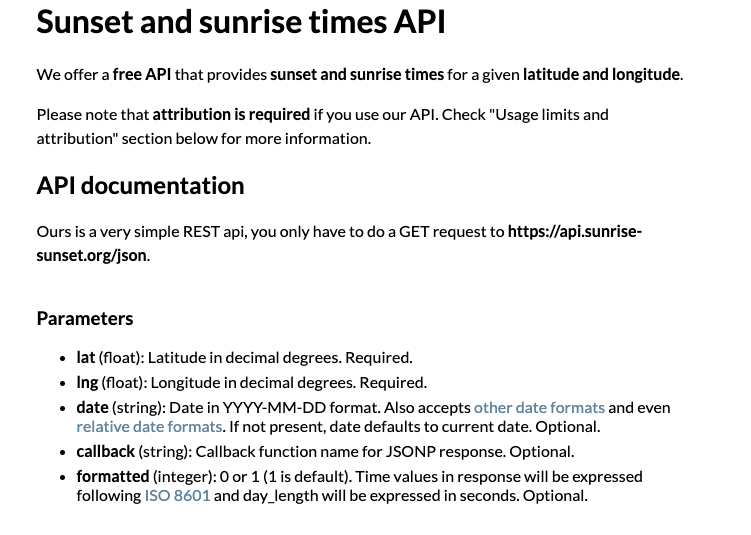

Nếu bạn chỉ muốn lấy những thông tin mà bạn yêu cầu, bạn có thể truyền vào các tham số parameters vào để lấy thông tin bạn cần, trong ví dụ này chúng ta sẽ sử dụng thư viện `requests` và api: `Sunset and sunrise times API`

Bạn có thể lấy thông tin kinh độ và vĩ độ tại đây: [Location info](https://www.latlong.net/)

In [8]:
# Define các tham số:
parameters = {
    "lat": "21.027763",
    "lng": "105.834160",
    "formatted": 0,
}

In [9]:
# Lấy kết quả
response = requests.get("https://api.sunrise-sunset.org/json", params=parameters)
response.raise_for_status()
print(response.text)

{"results":{"sunrise":"2023-10-21T22:53:28+00:00","sunset":"2023-10-22T10:28:57+00:00","solar_noon":"2023-10-22T04:41:12+00:00","day_length":41729,"civil_twilight_begin":"2023-10-21T22:32:07+00:00","civil_twilight_end":"2023-10-22T10:50:18+00:00","nautical_twilight_begin":"2023-10-21T22:06:08+00:00","nautical_twilight_end":"2023-10-22T11:16:17+00:00","astronomical_twilight_begin":"2023-10-21T21:40:16+00:00","astronomical_twilight_end":"2023-10-22T11:42:09+00:00"},"status":"OK"}


In [10]:
from datetime import datetime
# Lấy thông tin kết quả sunrise & sunset, lưu ý kết quả trả ra ở giờ UTC 00
data = response.json()
sunrise = int(data["results"]["sunrise"].split("T")[1].split(":")[0])
sunset = int(data["results"]["sunset"].split("T")[1].split(":")[0])
time_now = datetime.now().hour

### Bài tập 2: 

Gọi API và lấy tông tin thời gian mặt trời mọc của Hà Nội vào ngày 02/09/2023, Lưu ý thời gian phải dưới dạng UTC + 7

In [11]:
# Code của bạn ở đây